In [10]:
import os
import sys
import cv2
import torch
import random
import numpy as np

from pathlib import Path
from PIL import Image, ImageFilter
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel
import torchvision.transforms.functional as TF
import torch.nn.functional as F

PROJECT_ROOT = Path("/home/cavadalab/Documents/scsv/fungitastic2026_2")
DATASET_ROOT = Path("/data0/sebastian.cavada/datasets/FungiTastic/FungiTastic")
OUTPUT_ROOT = PROJECT_ROOT / "data_processed"
MODEL_NAME = os.environ.get("MODEL_NAME", "facebook/dinov3-vit7b16-pretrain-lvd1689m")
OUTPUT_NAME = os.environ.get("OUTPUT_NAME", "")
BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "4"))
NUM_WORKERS = int(os.environ.get("NUM_WORKERS", "8"))
SHARD_SIZE = int(os.environ.get("SHARD_SIZE", "512"))
SEED = 0
DTYPE = torch.bfloat16

sys.path.append(str(PROJECT_ROOT / "FungiTastic"))
from dataset.mask_fungi import MaskFungiTastic
from dataset.utils.mask_vis import get_image_shape, resize_mask_to_image

HUGGINGFACE_MODELS = [
    "facebook/dinov3-vits16-pretrain-lvd1689m",
    "facebook/dinov3-vits16plus-pretrain-lvd1689m",
    "facebook/dinov3-vitb16-pretrain-lvd1689m",
    "facebook/dinov3-vitl16-pretrain-lvd1689m",
    "facebook/dinov3-vith16plus-pretrain-lvd1689m",
    "facebook/dinov3-vit7b16-pretrain-lvd1689m",
]

SPLIT = os.environ.get("SPLIT", "test")
DEFAULT_BATCH_SIZE = 8
MODEL_LOAD_DTYPE = DTYPE
FEATURE_DTYPE = DTYPE
DATA_SUBSET = "FewShot"
DATASET_SIZE = os.environ.get("DATASET_SIZE", "720")
IMAGE_SIZE = 224 if DATASET_SIZE == "300" else 448
TASK = "closed"
SEG_TASK = "binary"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = DEVICE == "cuda"
BACKGROUND_TYPES = [
    # "crop",
    # "crop_black",
    # "masked_black",
    # "masked_blurred", # not needed for now what I am doing is a different analysis now
    "normal",
]
BACKGROUND = "normal"
MIN_BOX_AREA = 2500

def collate_batch(batch):
    images = [item[0] for item in batch]
    # from /home/cavadalab/Documents/scsv/fungitastic2026/FungiTastic/dataset/mask_fungi.py
    masks = [torch.from_numpy(resize_mask_to_image(item[1], get_image_shape(item[0]))).unsqueeze(0) for item in batch]    
    labels = [item[2] for item in batch]
    file_paths = [item[3] for item in batch]
    return images, masks, labels, file_paths

In [ ]:
dataset = MaskFungiTastic(
    root=str(DATASET_ROOT),
    split=SPLIT,
    size=DATASET_SIZE,
    task=TASK,
    data_subset=DATA_SUBSET,
    transform=None,
    seg_task=SEG_TASK,
    workers=8,
)

assert MODEL_NAME in HUGGINGFACE_MODELS, MODEL_NAME

dataloader_kwargs = {
    "batch_size": BATCH_SIZE,
    "shuffle": False,
    "num_workers": NUM_WORKERS,
    "collate_fn": collate_batch,
}
if NUM_WORKERS > 0:
    dataloader_kwargs["persistent_workers"] = True
    dataloader_kwargs["prefetch_factor"] = 2

dataloader = DataLoader(dataset, **dataloader_kwargs)

Generated color mapping for 6 unique labels: ['cap', 'fruiting_body', 'gills', 'ring', 'stem', 'unknown underside']


Loading weights: 100%|██████████| 687/687 [00:01<00:00, 384.22it/s]


In [12]:
class_counts = {}

for idx, (images, gt_masks, labels, file_paths) in enumerate(tqdm(dataloader, desc="Processing batches", unit="batch")):
    for label in labels:
        if label not in class_counts:
            class_counts[label] = 0
        class_counts[label] += 1

Processing batches: 100%|██████████| 16/16 [00:00<00:00, 18.13batch/s]


In [13]:
# class_counts
class_counts_labels_og = list(class_counts.keys())
class_counts_values_og = list(class_counts.values())

class_counts_labels_zero_n = [i for i in range(len(class_counts_labels_og))]

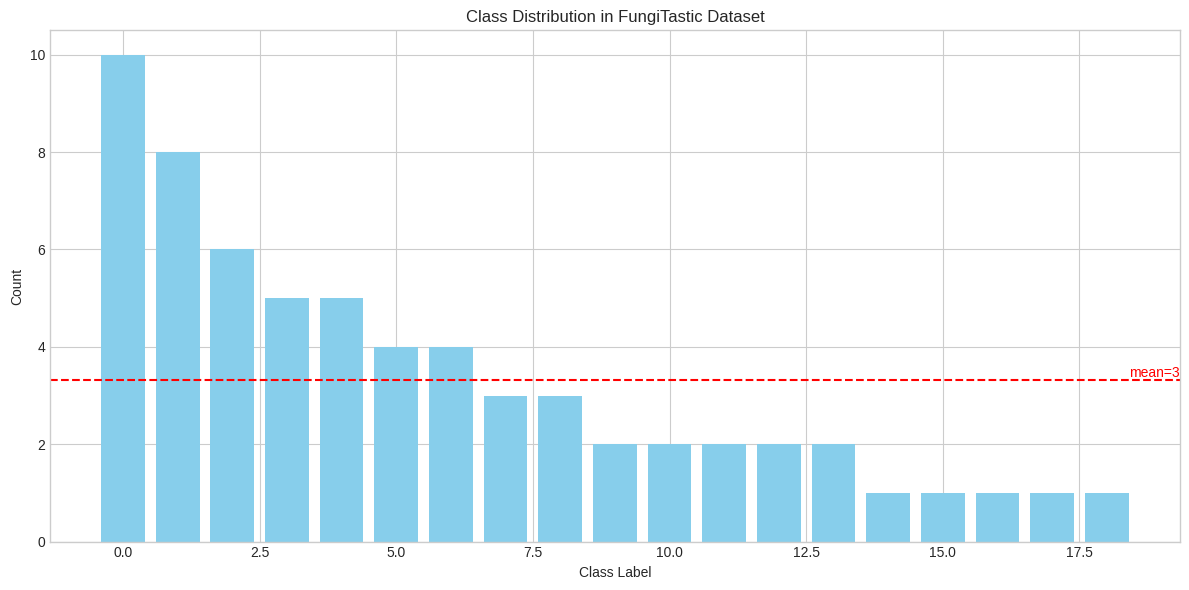

In [14]:
class_counts_labels_og_np = np.array(list(class_counts.keys()))

class_counts_values_og_np = np.array(list(class_counts.values()))
class_counts_values_og_np.sort()
class_counts_values_og_np = class_counts_values_og_np[::-1]

mean_count = np.mean(class_counts_values_og_np)

class_counts_labels_zero_n = [i for i in range(class_counts_labels_og_np.shape[0])]

# display barplot
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(class_counts_labels_zero_n, class_counts_values_og_np, color='skyblue')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.axhline(y=mean_count, linestyle='--', color='red', label=f'Mean Count: {mean_count:.2f}')
# optional label
plt.text(1.0, mean_count, f"mean={mean_count:.0f}",
         transform=plt.gca().get_yaxis_transform(),
         ha='right', va='bottom', color='red', fontsize=10)
plt.title('Class Distribution in FungiTastic Dataset')
plt.tight_layout()
plt.show()
